In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Ajout du dossier src au path pour importer ton script
sys.path.append(os.path.abspath("../src"))

from preprocessing import (
    clean_raw_data, 
    engineer_features, 
    impute_numeric, 
    encode_country_target, 
    remove_highly_correlated_features,
    ORDINAL_MAPPINGS
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Configuration esthétique
sns.set_theme(style="white")
%matplotlib inline

Dimensions initiales : (4372, 52)


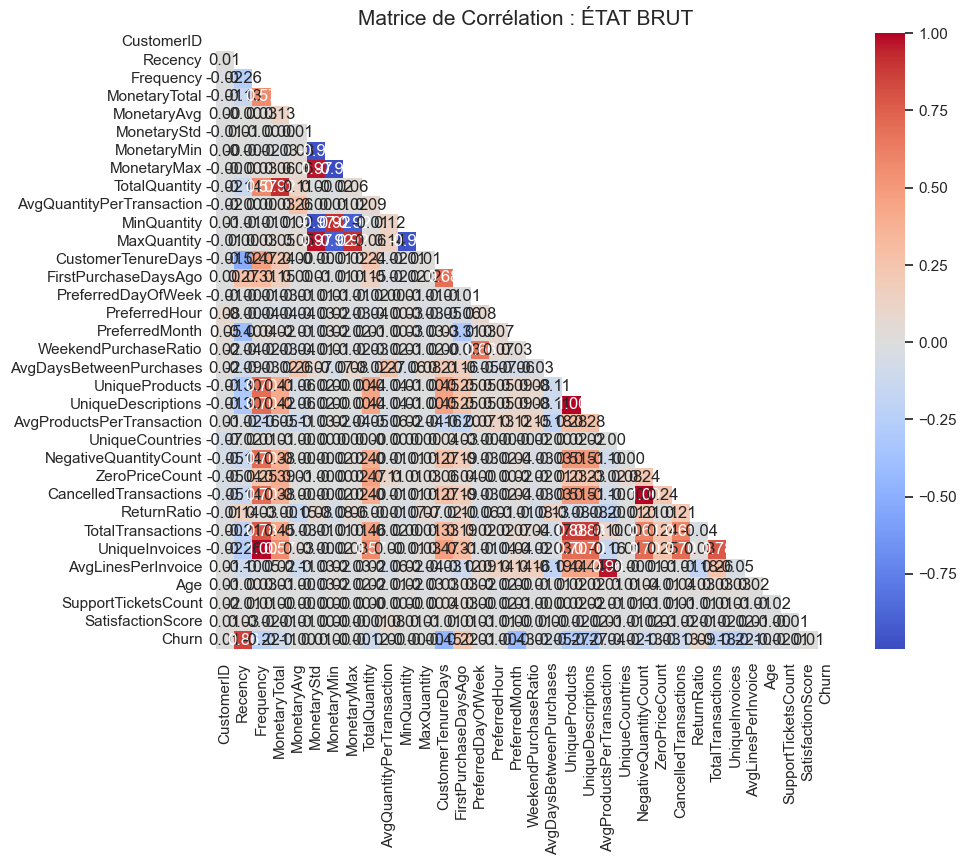

In [4]:
# 1. Chargement
df_raw = pd.read_csv('../data/raw/data.csv')
print(f"Dimensions initiales : {df_raw.shape}")

# 2. Visualisation de la corrélation brute (numérique uniquement)
plt.figure(figsize=(10, 8))
corr_before = df_raw.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_before, dtype=bool))

sns.heatmap(corr_before, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matrice de Corrélation : ÉTAT BRUT", fontsize=15)
plt.show()

In [5]:
# A. Nettoyage et Engineering
df_processed = clean_raw_data(df_raw)
df_processed = engineer_features(df_processed)

# B. Split (Obligatoire avant l'imputation et le target encoding pour éviter le data leakage)
X = df_processed.drop(columns=["Churn"])
y = df_processed["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# C. Imputation (Utilise le dossier models pour sauvegarder les artefacts)
os.makedirs("../models", exist_ok=True)
X_train, X_test = impute_numeric(X_train, X_test, "../models")

# D. Encodages (Ordinal + Target Country)
for col, mapping in ORDINAL_MAPPINGS.items():
    if col in X_train.columns:
        X_train[col] = X_train[col].map(mapping).fillna(-1)
X_train, X_test = encode_country_target(X_train, X_test, y_train, "../models")

# E. One-Hot Encoding (pour les variables catégorielles restantes)
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = pd.concat([
    X_train.drop(columns=cat_cols),
    pd.DataFrame(ohe.fit_transform(X_train[cat_cols]), 
                 columns=ohe.get_feature_names_out(cat_cols), 
                 index=X_train.index)
], axis=1)

print(f"Nombre de features après encodages complets : {X_train_encoded.shape[1]}")

[clean] Colonnes supprimées (inutiles) : ['NewsletterSubscribed']
[clean] MonetaryTotal : 0 valeurs aberrantes converties en NaN
[clean] RegistrationDate : 0 dates non convertibles (NaT)
[clean] RegistrationDate → RegYear, RegMonth, RegDay, RegWeekday
[clean] Nettoyage espaces terminé pour : ['Country', 'Gender', 'AccountStatus']
[clean] Colonnes après nettoyage brut : 54
[engineer] LastLoginIP → IP_IsPrivate + IP_FirstOctet
[engineer] Colonnes après feature engineering : 57
[impute] Colonnes imputées : ['AvgDaysBetweenPurchases', 'Age']
[encode_country] Colonne '../models' absente, étape ignorée.
Nombre de features après encodages complets : 125


d:\2eme_S2_ENIS\machineLearning\projet_ml_retail\src\preprocessing.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(
C:\Users\user\AppData\Local\Temp\ipykernel_14688\2625556399.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()



[clean] Traitement de la multicolinéarité (seuil > 0.8)...
    Variables colinéaires supprimées : ['MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'MinQuantity', 'MaxQuantity', 'UniqueDescriptions', 'CancelledTransactions', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'PreferredTimeOfDay', 'LoyaltyLevel', 'MonetaryPerDay', 'CustomerType_Perdu', 'Region_UK', 'ChurnRiskCategory_Critique', 'WeekendPreference_Weekend', 'ProductDiversity_Modéré', 'Country_Australia', 'Country_Brazil', 'Country_Japan', 'Country_Lithuania', 'Country_RSA', 'Country_United Kingdom']


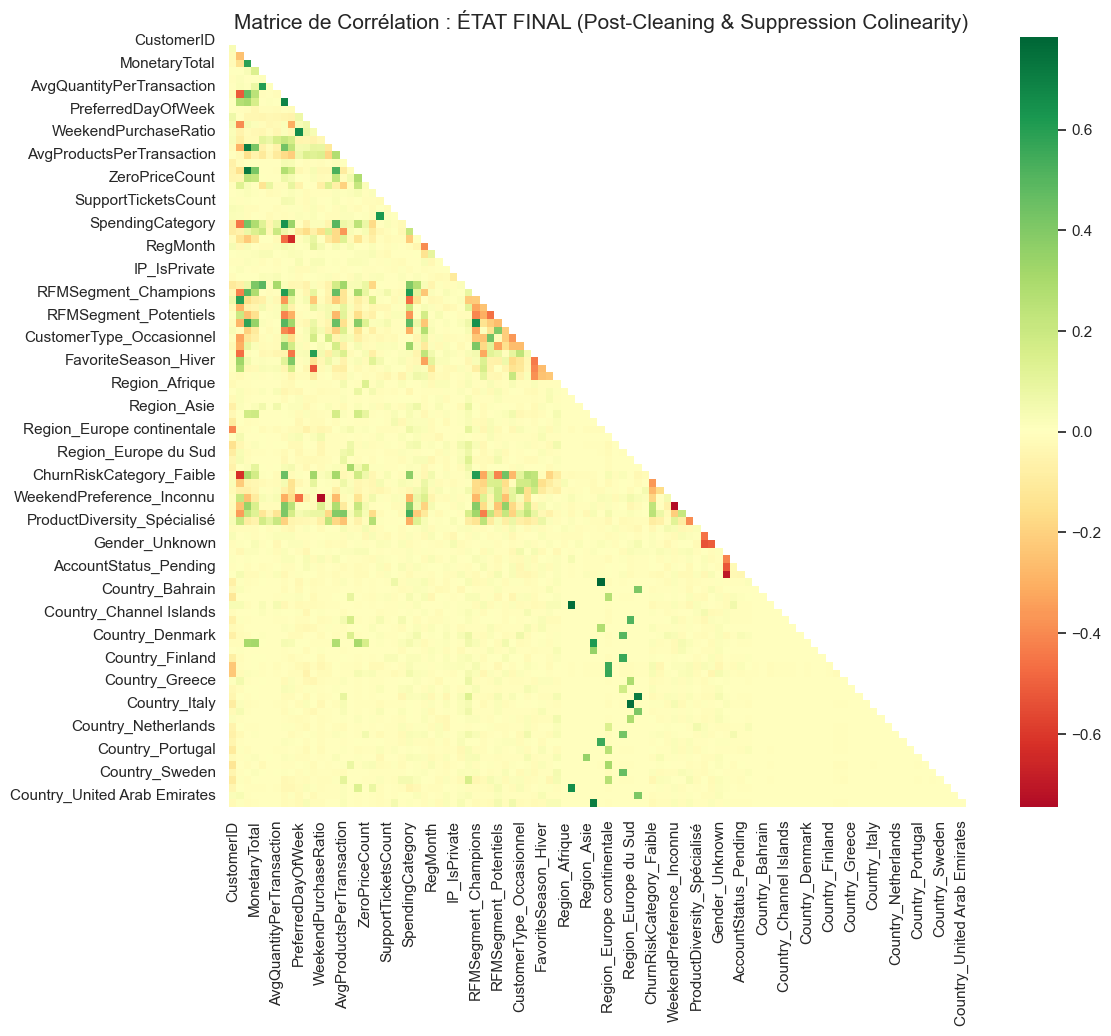

Vérification : 24 colonnes redondantes ont été supprimées.
Colonnes restantes : 101
Détail des suppressions : ['TotalQuantity', 'TotalTransactions', 'AvgLinesPerInvoice', 'CustomerType_Perdu', 'MonetaryMin', 'Country_Lithuania', 'PreferredTimeOfDay', 'Country_RSA', 'Region_UK', 'CancelledTransactions', 'Country_Australia', 'Country_Japan', 'Country_Brazil', 'UniqueDescriptions', 'LoyaltyLevel', 'ChurnRiskCategory_Critique', 'WeekendPreference_Weekend', 'ProductDiversity_Modéré', 'MinQuantity', 'MaxQuantity', 'MonetaryMax', 'UniqueInvoices', 'MonetaryPerDay', 'Country_United Kingdom']


In [7]:
# 1. Application de la suppression intelligente (seuil 0.8)
X_train_final, _ = remove_highly_correlated_features(X_train_encoded.copy(), X_train_encoded.copy())

# 2. Affichage de la matrice finale
plt.figure(figsize=(12, 10))
corr_after = X_train_final.corr()
mask_after = np.triu(np.ones_like(corr_after, dtype=bool))

sns.heatmap(corr_after, mask=mask_after, annot=False, cmap='RdYlGn', center=0)
plt.title("Matrice de Corrélation : ÉTAT FINAL (Post-Cleaning & Suppression Colinearity)", fontsize=15)
plt.show()

# 3. Bilan académique
cols_supprimees = set(X_train_encoded.columns) - set(X_train_final.columns)
print(f"Vérification : {len(cols_supprimees)} colonnes redondantes ont été supprimées.")
print(f"Colonnes restantes : {X_train_final.shape[1]}")
if len(cols_supprimees) > 0:
    print(f"Détail des suppressions : {list(cols_supprimees)}")